### Build a Basic Chatbot with LangGraph(Graph API)

In [6]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [7]:
class State(TypedDict):
    # Messages have the type "list". The "add_messages function"
    # in the annoation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(
    model="qwen/qwen3-32b"
)

In [42]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000172CADCCCD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000172CADCD6D0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [43]:
llm=init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000172C96595B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000172CAE288A0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [44]:
# Node Functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [45]:
graph_builder=StateGraph(State)

## Adding Node
graph_builder.add_node("llmchatbot",chatbot)

## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)


## Compile the graph
graph=graph_builder.compile()

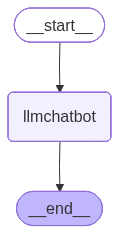

In [46]:
## Visualize the graph

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [47]:
response=graph.invoke({"messages":"Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='cf320bea-6f04-4490-a477-87241ddb7cf6'),
  AIMessage(content='<think>\nOkay, the user said "Hi". That\'s pretty open-ended. I should respond in a friendly and welcoming way to encourage them to ask their question or share what\'s on their mind. Maybe something like, "Hello! How can I assist you today?" That keeps the door open for any type of query they might have. Let me make sure the tone is positive and approachable. Yeah, that should work. I\'ll go with that.\n</think>\n\nHello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 9, 'total_tokens': 113, 'completion_time': 0.233460206, 'completion_tokens_details': None, 'prompt_time': 0.000428953, 'prompt_tokens_details': None, 'queue_time': 0.050444007, 'total_time': 0.233889159}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'o

In [48]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s pretty open-ended. I should respond in a friendly and welcoming way to encourage them to ask their question or share what\'s on their mind. Maybe something like, "Hello! How can I assist you today?" That keeps the door open for any type of query they might have. Let me make sure the tone is positive and approachable. Yeah, that should work. I\'ll go with that.\n</think>\n\nHello! How can I assist you today?'

In [49]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user greeted me and asked how I'm doing. I should respond politely and show enthusiasm. I need to keep it friendly and open for further conversation. I'll thank them for asking and let them know I'm here to help. I should encourage them to share what's on their mind. Keep it simple and approachable without any special formatting.
</think>

Hello! Thank you for asking - I'm doing well, and I'm excited to chat with you! How can I assist you today? Feel free to share anything on your mind, and I'll do my best to help. 😊


## ChatBot with Tools

In [50]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? | IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [51]:
## Custom Function
def multiply(a:int, b:int)->int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int
        
    Return:
        int: output int
    """
    return a*b


In [52]:
tools=[tool,multiply]

In [53]:
llm_with_tools=llm.bind_tools(tools)

In [54]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000172C96595B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000172CAE288A0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for com

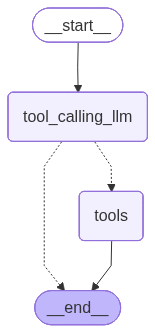

In [55]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

## Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [56]:
response=graph.invoke({"messages":"What is the today AI news"})

In [57]:
response["messages"][-1].content

'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/chinas-robot-run-hotel-opens-public-2027", "title": "China’s robot-run hotel opens to public in 2027 - Fox News", "score": 0.53619206, "published_date": "Sun, 05 Jul 2026 10:58:03 GMT", "content": "* #### Fox News AI Newsletter: American manufacturer says AI is creating jobs, not replacing them. * #### The trick to smoother streaming at home and on the road. # China’s robot-run hotel opens to public in 2027. ## A hotel on China’s West Artificial Island will use robots for check-in, luggage, cleaning, room service and guest support. Pudu Robotics has announced what it calls the first \\"full-scenario robot-serviced hotel.\\" The project will use robots across the entire guest experience, from reception and room service to cleaning, food preparation and guest support. Pudu Robotics says its robot-run hotel will use AI-powered machines across check-in, room se

In [58]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the today AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9m8s1s61f)
 Call ID: 9m8s1s61f
  Args:
    query: AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/chinas-robot-run-hotel-opens-public-2027", "title": "China’s robot-run hotel opens to public in 2027 - Fox News", "score": 0.53619206, "published_date": "Sun, 05 Jul 2026 10:58:03 GMT", "content": "* #### Fox News AI Newsletter: American manufacturer says AI is creating jobs, not replacing them. * #### The trick to smoother streaming at home and on the road. # China’s robot-run hotel opens to public in 2027. ## A hotel on China’s West Artificial Island

In [59]:
response=graph.invoke({"messages":"What is 2*3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2*3
================================== Ai Message ==================================
Tool Calls:
  multiply (f0zwwmawp)
 Call ID: f0zwwmawp
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [60]:
response=graph.invoke({"messages":"What is 2 multiply by 3 and then multiply 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3 and then multiply 3
================================== Ai Message ==================================
Tool Calls:
  multiply (ws3fy0vwp)
 Call ID: ws3fy0vwp
  Args:
    a: 2
    b: 3
  multiply (8sd2xz3e4)
 Call ID: 8sd2xz3e4
  Args:
    a: 6
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: multiply

18


In [61]:
response=graph.invoke({"messages":"What is recent India news and then multiply 4 by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is recent India news and then multiply 4 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3b2161zqx)
 Call ID: 3b2161zqx
  Args:
    query: recent India news
    time_range: day
    topic: news
  multiply (grc99k8bt)
 Call ID: grc99k8bt
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent India news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.indiasnews.net/news/279166982/will-build-entire-electronics-value-chain-semiconductor-growth-next-phase-of-make-in-india-pm-modi", "title": "Will build entire electronics value chain; Semiconductor growth next phase of 'Make in India': PM Modi - India's News.Net", "score": 0.6455898, "published_date": "Sat, 04 Jul 2026 18:17:11 GMT", "content": "Sanand (Guj

### ReAct Agent Architecture

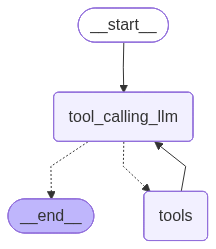

In [62]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

## Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [64]:
response=graph.invoke({"messages":"What is recent India news and then multiply 4 by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is recent India news and then multiply 4 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5tb81z127)
 Call ID: 5tb81z127
  Args:
    query: recent India news
    time_range: week
    topic: news
  multiply (q2h4szv1r)
 Call ID: q2h4szv1r
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent India news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/india/indias-jana-small-finance-bank-promoter-bond-rating-downgraded-after-repayment-2026-07-01/", "title": "TPG-backed Jana Holdings bond rating downgraded after repayment extension - Reuters", "score": 0.6783488, "published_date": "Wed, 01 Jul 2026 07:47:16 GMT", "content": "Exclusive news, data and analytics for financial market profes

## Adding Memory in Agentic Graph

In [65]:
response=graph.invoke({"messages":"Hello my name is Harsh"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Harsh
================================== Ai Message ==================================

Hello Harsh! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know!


In [66]:
response=graph.invoke({"messages":"What is my name"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have access to personal information or previous interactions. You'll need to provide your name for me to address you by name.


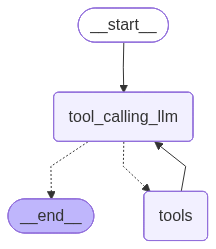

In [67]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

## Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## Compile the graph
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [68]:
config={"configurable":{"thread_id":"1"}}

In [69]:
response=graph.invoke({"messages":"Hy my name is harsh"},config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hy my name is harsh
================================== Ai Message ==================================

Hello, Harsh! How can I assist you today? 😊


In [70]:
response["messages"][-1].content

'Hello, Harsh! How can I assist you today? 😊'

In [71]:
response=graph.invoke({"messages":"Hy what is my name?"},config=config)
print(response["messages"][-1].content)

Hello again! Your name is Harsh. 😊 How can I assist you today?


In [72]:
response=graph.invoke({"messages":"Hy do you remember my name?"},config=config)
print(response["messages"][-1].content)

Hello Harsh! Of course, I remember your name. 😊 How can I assist you today?


## Streaming

In [3]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [10]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

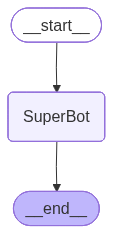

In [11]:
graph=StateGraph(State)

# Nodes
graph.add_node("SuperBot",superbot)

# Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

from IPython.display import Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [12]:
## Invocation
config = {"configurable": {"thread_id":"1"}}

graph_builder.invoke({"messages":"Hi, my name is Harsh and i like cricket"},config=config)

{'messages': [HumanMessage(content='Hi, my name is Harsh and i like cricket', additional_kwargs={}, response_metadata={}, id='77cc1230-816e-482e-8121-de9a5e0d8800'),
  AIMessage(content="<think>\nOkay, the user introduced himself as Harsh and mentioned he likes cricket. I need to respond appropriately. Let me start with a friendly greeting using his name. Since he likes cricket, I should ask him about it to engage in a conversation. Maybe ask which team he supports or any favorite players. Keep it open-ended so he can elaborate. Also, make sure to invite him to ask questions if he has any. Keep the tone positive and welcoming. Let me put that together in a natural way without any markdown. Keep sentences simple and conversational.\n</think>\n\nHi Harsh! Nice to meet you. 🏏 I'm glad to hear you're a cricket fan—I could chat about it all day! Do you follow a particular team or player closely? Or maybe you're more into watching the IPL? Let me know what you'd like to discuss about the gam

### Streaming
Methods: .stream() and astream()

- These methods are sync and async method for streaming back results.

Additional parameters in streaming nodes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [14]:
## Create a thread

config={"configurable":{"thread_id":"3"}}

for chunks in graph_builder.stream({"messages":"Hi, my name is Harsh and i like football"},config,stream_mode="updates"):
    print(chunks)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced themselves as Harsh and mentioned they like football. I should respond in a friendly way. Let me start by welcoming Harsh. Then, since they like football, I can ask about their favorite team or what they enjoy most about the game. I need to make sure the response is positive and engaging. Maybe add an emoji related to football to keep it light. Also, keep the tone casual and open for conversation. Let me check for any grammar issues and ensure it's concise.\n</think>\n\nHello Harsh! 🤝 Welcome! I'm glad to meet you. Football is amazing—do you support a particular team, or is there something specific you love about the game? Let's chat more about it! ⚽✨", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 19, 'total_tokens': 175, 'completion_time': 0.369296392, 'completion_tokens_details': None, 'prompt_time': 0.000863358, 'prompt_tokens_details': None, 'queue

In [15]:
for chunks in graph_builder.stream({"messages":"Hi, my name is Harsh and i like football"},config,stream_mode="values"):
    print(chunks)

{'messages': [HumanMessage(content='Hi, my name is Harsh and i like football', additional_kwargs={}, response_metadata={}, id='bf36b102-a410-4440-9dc3-1dac3e231ece'), AIMessage(content="<think>\nOkay, the user introduced themselves as Harsh and mentioned they like football. I should respond in a friendly way. Let me start by welcoming Harsh. Then, since they like football, I can ask about their favorite team or what they enjoy most about the game. I need to make sure the response is positive and engaging. Maybe add an emoji related to football to keep it light. Also, keep the tone casual and open for conversation. Let me check for any grammar issues and ensure it's concise.\n</think>\n\nHello Harsh! 🤝 Welcome! I'm glad to meet you. Football is amazing—do you support a particular team, or is there something specific you love about the game? Let's chat more about it! ⚽✨", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 19, 'total_tokens

In [16]:
## Create a thread

config={"configurable":{"thread_id":"5"}}

for chunks in graph_builder.stream({"messages":"Hi, my name is Harsh and i like football"},config,stream_mode="updates"):
    print(chunks)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, Harsh mentioned his name and that he likes football. I should respond with something friendly and welcoming. Maybe start by greeting him and acknowledging his interest in football. I should ask him a question to keep the conversation going, like what position he plays or if he's into any particular team. Keeping it open-ended so he can talk more. Also, make sure the tone is positive and encouraging. Let me check for grammar and flow. Yeah, that should work.\n</think>\n\nHello Harsh! It's great to meet you. Football is an amazing sport—do you play it or just enjoy watching? If you play, what position are you on the field? 🏈", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 19, 'total_tokens': 160, 'completion_time': 0.325628006, 'completion_tokens_details': None, 'prompt_time': 0.000566608, 'prompt_tokens_details': None, 'queue_time': 0.16058937, 'total_time': 0.326194614}, '

In [18]:

for chunks in graph_builder.stream({"messages":"Hi, my name is Harsh and i also like cricket"},config,stream_mode="values"):
    print(chunks)

{'messages': [HumanMessage(content='Hi, my name is Harsh and i like football', additional_kwargs={}, response_metadata={}, id='9ab78f89-5235-40ab-acbd-7e5e13dc4c80'), AIMessage(content="<think>\nOkay, Harsh mentioned his name and that he likes football. I should respond with something friendly and welcoming. Maybe start by greeting him and acknowledging his interest in football. I should ask him a question to keep the conversation going, like what position he plays or if he's into any particular team. Keeping it open-ended so he can talk more. Also, make sure the tone is positive and encouraging. Let me check for grammar and flow. Yeah, that should work.\n</think>\n\nHello Harsh! It's great to meet you. Football is an amazing sport—do you play it or just enjoy watching? If you play, what position are you on the field? 🏈", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 19, 'total_tokens': 160, 'completion_time': 0.325628006, 'completi

In [22]:

config={"configurable":{"thread_id":"5"}}
async for chunks in graph_builder.astream_events({"messages":"Hi, my name is Harsh and i also like cricket"},config,version="v2"):
    print(chunks)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my name is Harsh and i also like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f370e-8d91-79f1-9982-aff5290fc544', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Harsh and i like football', additional_kwargs={}, response_metadata={}, id='9ab78f89-5235-40ab-acbd-7e5e13dc4c80'), AIMessage(content="<think>\nOkay, Harsh mentioned his name and that he likes football. I should respond with something friendly and welcoming. Maybe start by greeting him and acknowledging his interest in football. I should ask him a question to keep the conversation going, like what position he plays or if he's into any particular team. Keeping it open-ended so he can talk more. Also, make sure the tone is positive and encouraging. Let me check for grammar and flow. Yeah, that should work.\n</think>\n\nHello